# [1교시]

In [ ]:
# 대표적인 딥러닝 모델
# 케라스, 파이토치
# 케라스 : 전체적인 내용을 살펴본다
# 파이토치 : 세부적으로 구현하는 방향으로 간다
# 모델 컴파일 : compile() 메서드를 호출하여 사용할 손실 함수와 optimizer를 지정
    # "sparse+categorical_crossentropy"손실을 사용
    # 샘플마다 클래스별 타깃 확률을 가지고 있다면 "categorical_crossentropy"손실을 사용

# optimizer : model의 학습을 튜닝해주는 역할, 경사하강법에서 오차가 줄어들도록 도와줌
             
# 확률적 경사 하강법 : 어디로 갈 지 모르기 때문에 좌우로 이동을 한다
# concat을 사용하는 이유 : wide & deep 신경망 -> 성능이 더 좋아진다.

# 시퀀설 API와 함수형 API 비교

# 훈련된 케라스 모델 저장 : model.save("my_keras_model", save_format="tf")
    # 모델 로드 : model = tf.keras.models.load_model("my_keras_model")
              # y_pred_main, y_pred_aux = model.predict((X_new_wide, X_new_deep))

# callback : 어떤 이벤트가 발생했을 때 함수 실행
    # ModelCheckpoint는 훈련하는 동안 일정한 간격으로 모델의 체크포인트를 저장
        # 기본적으로 매 에포크의 끝에서 호출
        # checkpoint_cb = tf.keras.callbacks.Model

# [2교시]

In [1]:
 # 캘리포니아 주택 데이터셋
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
data = fetch_california_housing()

# (x, x, y, y)
x_train_full, x_test, y_train_full, y_test = train_test_split(data.data, data.target, random_state=42) # test값을 주지 않으면 75 : 25
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, random_state=42)
x_train.shape, x_val.shape, x_test.shape

((11610, 8), (3870, 8), (5160, 8))

- 훈련데이터 가중치를 학습
- 미니배치 경사하강법 + 역전파
- 손실을 줄이도록 파라메터를 반복 업데이트

In [2]:
import tensorflow as tf

c:\miniconda\envs\myenv\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
x_train.shape[1:]

(8,)

In [4]:
tf.random.set_seed(42)
normal_layer = tf.keras.layers.Normalization(input_shape=(8,))
model = tf.keras.Sequential([
    normal_layer,
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss = 'mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normal_layer.adapt(x_train)
history = model.fit(x_train, y_train ,epochs=50, validation_data=(x_val,y_val))

Epoch 1/50


c:\miniconda\envs\myenv\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.8544 - loss: 0.7300 - val_RootMeanSquaredError: 1.4497 - val_loss: 2.1017
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6088 - loss: 0.3706 - val_RootMeanSquaredError: 0.5882 - val_loss: 0.3460
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6005 - loss: 0.3606 - val_RootMeanSquaredError: 1.3846 - val_loss: 1.9172
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5787 - loss: 0.3349 - val_RootMeanSquaredError: 0.7598 - val_loss: 0.5773
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5833 - loss: 0.3403 - val_RootMeanSquaredError: 1.7099 - val_loss: 2.9237
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5739 - loss: 0.3293 - val_RootMeanSquaredError: 2.0739 - val_loss: 4.3012
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5884 - loss: 0.3462 -

In [6]:
# 성능 측정
model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - RootMeanSquaredError: 0.5311 - loss: 0.2820


[0.2820326089859009, 0.531067430973053]

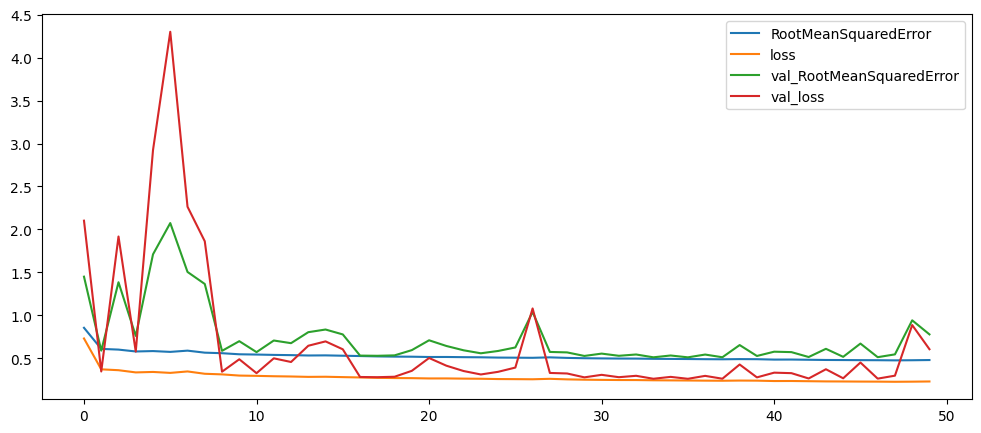

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
plt.plot(range(50), history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
plt.plot(range(50), history.history['loss'], label = 'loss')
plt.plot(range(50), history.history['val_RootMeanSquaredError'], label = 'val_RootMeanSquaredError')
plt.plot(range(50), history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

# [3교시]

In [8]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test, y_predict)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step


0.7868585625798771

In [9]:
from sklearn.ensemble import RandomForestRegressor
sk_model = RandomForestRegressor(random_state=42)
sk_model.fit(x_train, y_train)
sk_y_predict = sk_model.predict(x_test)
r2_score(y_test, sk_y_predict)

0.8001601142626265

함수형 API를 사용한 복잡한 모델 구축
- wide & deep 신경망 : 입력의 전부 또는 일부를 출력레이어 직접 연결
- 선형관계와 비선형표현을 동시에 학습해 편향/분산의 균형을 맞춤

In [11]:
import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(42)
input = tf.keras.layers.Input(shape=x_train.shape[1:])
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer2 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer3 = tf.keras.layers.Dense(50, activation='relu')
output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

normalized = normalization_layer(input)
hidden1 = hidden_layer1(normalized)
hidden2 = hidden_layer2(hidden1)
hidden3 = hidden_layer3(hidden2)
concat = concat_layer([normalized, hidden3])
output = output_layer(concat)

model = tf.keras.Model(inputs = [input], outputs = [output])
model.summary() #파라미터 개수 확인, 데이터 수에 비해 과도하면 과적합 위험

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        450 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 58)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,626 (21.98 KB)

 Trainable params: 5,609 (21.91 KB)

 Non-trainable params: 17 (72.00 B)

In [12]:
# 정규화를 하겠다는 것이 아닌 정규화를 적용하겠고 선언하는 것임
model.compile(loss = 'mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normalization_layer.adapt(x_train)
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.9290 - loss: 0.8631 - val_RootMeanSquaredError: 1.2145 - val_loss: 1.4749
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.6252 - loss: 0.3909 - val_RootMeanSquaredError: 1.1827 - val_loss: 1.3988
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6129 - loss: 0.3756 - val_RootMeanSquaredError: 1.3843 - val_loss: 1.9163
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5873 - loss: 0.3450 - val_RootMeanSquaredError: 0.7339 - val_loss: 0.5385
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5813 - loss: 0.3379 - val_RootMeanSquaredError: 1.4936 - val_loss: 2.2310
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5735 - loss: 0.3289 - val_RootMeanSquaredError: 1.5017 - val_loss: 2.2552
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5836 - los

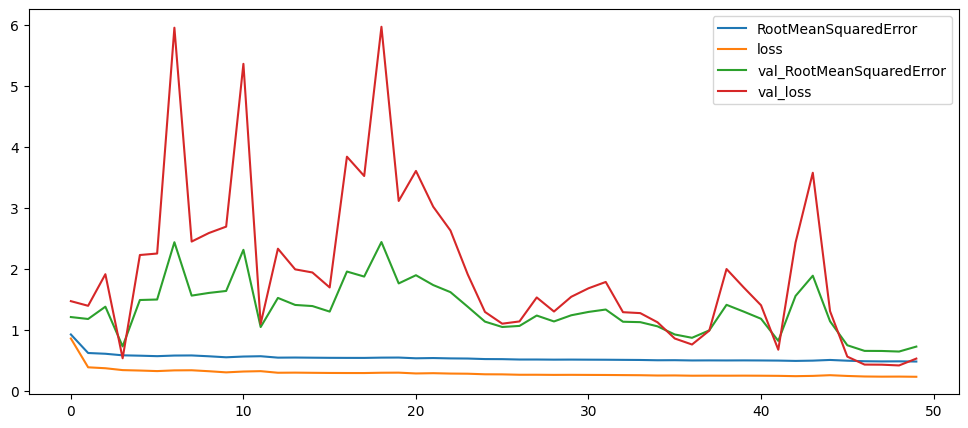

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(range(50), history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
ax.plot(range(50), history.history['loss'], label = 'loss')
ax.plot(range(50), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
ax.plot(range(50), history.history['val_loss'], label='val_loss')
ax.legend()
plt.show()

In [10]:
from sklearn.metrics import r2_score
y_predict = model.predict(x_test)
r2_score(y_test, y_predict)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step


0.7868585625798771

# [4교시]

In [ ]:
# 딥러닝의 세계에는 기존의 알고리즘을 분석하기보다는 다양하게 시도하면서 알고리즘을 개발하는게 많다.

In [11]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
data = fetch_california_housing()

x_train_full,x_test,y_train_full,y_test =  train_test_split(data.data, data.target, random_state=42)  # 75 : 25
x_train,x_val,y_train,y_val = train_test_split(x_train_full,y_train_full,random_state=42)
x_train.shape, x_val.shape, x_test.shape


import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(42)
input = tf.keras.layers.Input(shape=x_train.shape[1:])
normalization_layer  =tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(30,activation='relu')
output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

normalized = normalization_layer(input)
hidden1 = hidden_layer1(normalized)
concat =  concat_layer([normalized, hidden1])
output = output_layer(concat)

model = tf.keras.Model(inputs = [input], outputs= [output])

model.summary()  # 파라미터 개수 확인 ?? 데이터수에 비해 과도하면 과적합 위험

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 326 (1.28 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 17 (72.00 B)

In [ ]:

model.compile(loss = 'mse', optimizer='adam', metrics=['RootMeanSquaredError'])
normalization_layer.adapt(x_train)
epochs = 30
history = model.fit(x_train, y_train ,epochs=epochs, validation_data=(x_val,y_val))

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5733 - loss: 0.3287 - val_RootMeanSquaredError: 0.6370 - val_loss: 0.4057
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5669 - loss: 0.3214 - val_RootMeanSquaredError: 0.6004 - val_loss: 0.3605
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5672 - loss: 0.3217 - val_RootMeanSquaredError: 0.7339 - val_loss: 0.5387
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5661 - loss: 0.3205 - val_RootMeanSquaredError: 0.7841 - val_loss: 0.6147
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5681 - loss: 0.3227 - val_RootMeanSquaredError: 1.0139 - val_loss: 1.0280
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5672 - loss: 0.3217 - val_RootMeanSquaredError: 1.0178 - val_loss: 1.0360
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.569

In [ ]:
x_train_wide,x_train_deep =  x_train[:, :5], x_train[:,2:]
x_val_wide,x_val_deep =  x_val[:, :5], x_val[:,2:]
x_test_wide,x_test_deep =  x_test[:, :5], x_test[:,2:]


input_wide = tf.keras.layers.Input(shape=[5])  # 0 ~ 4 특성
input_deep = tf.keras.layers.Input(shape=[6])  # 2 ~ 7
norm_layer_wide = tf.keras.layers.Normalization()
norm_layer_deep = tf.keras.layers.Normalization()
norm_wide = norm_layer_wide(input_wide)
norm_deep = norm_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation='relu')( norm_deep )
hidden2 = tf.keras.layers.Dense(30, activation='relu')( hidden1 )

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

aux_output = tf.keras.layers.Dense(1)(hidden2)

model = tf.keras.Model(inputs = [input_wide, input_deep], outputs = [output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss =('mse','mse'), loss_weights=(0.9,0.1) , optimizer=optimizer,
              metrics=['RootMeanSquaredError','RootMeanSquaredError'])

norm_layer_wide.adapt(x_train_wide)
norm_layer_deep.adapt(x_train_deep)
history = model.fit(
    (x_train_wide, x_train_deep), (y_train,y_train), epochs=20,
    validation_data = ( (x_val_wide, x_val_deep), (y_val, y_val)     )
)
     

Epoch 1/4
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_8_RootMeanSquaredError: 1.2135 - dense_8_loss: 1.4721 - dense_9_RootMeanSquaredError: 1.5291 - dense_9_loss: 2.3372 - loss: 1.5591 - val_dense_8_RootMeanSquaredError: 1.7459 - val_dense_8_loss: 3.0466 - val_dense_9_RootMeanSquaredError: 1.7634 - val_dense_9_loss: 3.1082 - val_loss: 3.0542
Epoch 2/4
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_8_RootMeanSquaredError: 0.6997 - dense_8_loss: 0.4896 - dense_9_RootMeanSquaredError: 0.8599 - dense_9_loss: 0.7394 - loss: 0.5145 - val_dense_8_RootMeanSquaredError: 0.7860 - val_dense_8_loss: 0.6176 - val_dense_9_RootMeanSquaredError: 1.1588 - val_dense_9_loss: 1.3424 - val_loss: 0.6904
Epoch 3/4
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_8_RootMeanSquaredError: 0.6555 - dense_8_loss: 0.4298 - dense_9_RootMeanSquaredError: 0.7955 - dense_9_loss: 0.6328 - loss: 0.4500 - val_dense_8_RootMeanSquaredError: 0.6235 - val_dense_8_loss: 0.3887 - val_dense_9_RootMeanSquaredError: 0.9989

In [16]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 6)         │         13 │ input_layer_4[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30)        │        210 │ normalization_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 5)         │         11 │ input_layer_3[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30)        │        930 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 35)        │          0 │ normalization_3[… │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         36 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         31 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [17]:
model.evaluate( (x_test_wide, x_test_deep),(y_test,y_test) )

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - dense_8_RootMeanSquaredError: 0.6323 - dense_8_loss: 0.3999 - dense_9_RootMeanSquaredError: 0.7511 - dense_9_loss: 0.5657 - loss: 0.4162


[0.4162086546421051,
 0.39989325404167175,
 0.5656747221946716,
 0.6322689056396484,
 0.7511399388313293]

In [18]:
model.predict( (x_test_wide, x_test_deep) )

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step


[array([[0.62620187],
        [1.983188  ],
        [3.361728  ],
        ...,
        [1.4734486 ],
        [2.4250312 ],
        [3.5246718 ]], dtype=float32),
 array([[0.6470316],
        [2.152837 ],
        [2.6845126],
        ...,
        [1.112597 ],
        [2.2202916],
        [2.995996 ]], dtype=float32)]

In [19]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 1.177  , 2.631  , 4.815  ])

# [5교시]

In [20]:
import torch
import torch.nn as nn
torch.manual_seed(42)

In [21]:
# 예측값과 정답값(회귀)
pred = torch.tensor([2.5, 5.0, 7.5])
target = torch.tensor([3.0, 5.0, 7.0])

# pytorch에서 제공하는 MSELoss 함수
mse_buildin = nn.MSELoss()(pred, target)

# 수식기반 수작업
mse_manual = torch.mean((pred - target) ** 2)
print(f"mse_buildin: {mse_buildin}")
print(f"mse_manual: {mse_manual}")

mse_buildin: 0.1666666716337204
mse_manual: 0.1666666716337204


$$
BCE = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]
$$

In [22]:
# 단일샘플 y = 1일 때, 계산 식은 -log(y_hat) 단순화되고, 그래서 정답 확률이 높을수록 손실이 낮아지는 형태가 된다.
y = torch.tensor([1.0])         # 정답 확률이 높음
yhat_good = torch.tensor([0.9])     # 정답 확률이 낮음
yhat_bad = torch.tensor([0.1])

# 수작업 계산
bce_good_manual = -(y*torch.log(yhat_good) + (1-y)*torch.log(1-yhat_good))
bce_bad_manual = - (y*torch.log(yhat_bad) + (1-y)*torch.log(1-yhat_bad))

# 내장된 BCE
bce_good_builtin = nn.BCELoss()(yhat_good, y)
bce_bad_builtin = nn.BCELoss()(yhat_bad, y)
print(f"bce_good_manual: {bce_good_manual}")
print(f"bce_bad_manual: {bce_good_manual}")
print(f"bce_good_manual: {bce_good_manual}")
print(f"bce_bad_manual: {bce_good_manual}")

bce_good_manual: tensor([0.1054])
bce_bad_manual: tensor([0.1054])
bce_good_manual: tensor([0.1054])
bce_bad_manual: tensor([0.1054])


# [6교시]

In [23]:
# BCE 배치계산
prob_pred = torch.tensor([0.9, 0.2, 0.4])
label = torch.tensor([1.0, 0.0, 1.0])
nn.BCELoss()(prob_pred, label)

tensor(0.4149)

$$
CE = -\sum_{i=1}^{m} y_i\log(\hat{y}_i)
$$

In [24]:
# 클래스 3개 [고양이, 강아지, 토끼] 정답이 강아지 (index=1)
target_index = torch.tensor([1])
one_hot = torch.tensor([[0.0, 1.0, 0.0]]) # 원-핫 인코딩된 정답

# 좋은 예측과 나쁜 예측
p_good = torch.tensor([0.2, 0.7, 0.1])
p_bad = torch.tensor([0.7, 0.2, 0.1])

# 수작업
ce_good_manual = -(one_hot*torch.log(p_good)).sum()
ce_bad_manual = -(one_hot*torch.log(p_bad)).sum()

# torch bce     logits 입력 log(p)
torch.log(p_good).unsqueeze(0).unsqueeze(2).shape   # unsqueeze : 차수를 1개 더 만들어준다
ce_loss = nn.CrossEntropyLoss()
ce_good_builtin = ce_loss(torch.log(p_good).unsqueeze(0), target_index)
ce_bad_builtin = ce_loss(torch.log(p_bad).unsqueeze(0), target_index)

print(ce_good_manual, ce_good_builtin)
print(ce_bad_manual, ce_bad_builtin) 

tensor(0.3567) tensor(0.3567)
tensor(1.6094) tensor(1.6094)


In [26]:
from sklearn.datasets import load_diabetes # 회귀
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
X, y  = load_diabetes(return_X_y=True)

scaler = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(x_train_t.shape)
reg_model = nn.Sequential(
    nn.Linear(x_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)

mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)   # 0.01

epochs = 300
for _ in range(epochs):
    optimizer.zero_grad()   # 이전가중치 초기화
    pred = reg_model(x_train_t)
    loss = mse_loss(pred, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step() # 각 계산과정의 가중치와 바이어스를 업데이트

with torch.no_grad():
    test_pred = reg_model(x_test_t)
    test_mse = mse_loss(test_pred, y_test_t)

# test_mse 텐서에 들어 있어서 보통 출력이나 기타 산술연산이 필요하면 꺼내야 한다, '.item'을 통해서.

print(f'test mse : {test_mse.item():.4f}')

torch.Size([331, 10])
test mse : 2954.2180


# [7교시]

3종세트 중요하니 잘 알아두는게 좋음
- loss.backward()
- optimizer.step()
- optimizer.zero_grad()


In [27]:
# 결정계수로 mse의 값이 좋은지 나쁜지 확인한다
from sklearn.metrics import r2_score
r2_score(y_test_t, test_pred)

0.465753436088562

In [ ]:
# 0. from sklearn.datasets import load_breast_cancer
# 1. 딥러닝 레이어 Sequential에서 입력을 받는 부분을 수정, feature 개수
# 2. 출력 레이어의 활성화 함수로 시그모이드
# 3. 손실함수 nn.BCELoss()
# 추론 with ...     0.5보다 크면 1, 그렇지않으면 0으로 변경

In [34]:
from sklearn.datasets import load_breast_cancer
# 1. 딥러닝 레이어 sequential에서 입력을 받는 부분을  수정 피처개수
# 2 출력레이어의 활성화 함수로 시그모이드
# 3. 손실함수 nn.BCELoss()
# 추론  with .....  0.5보다 크면 1 그렇지 않으면 0 변경

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
X, y = load_breast_cancer(return_X_y= True)

scaler = StandardScaler()
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42)
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

print(x_train_t.shape)
reg_model  = nn.Sequential(
    nn.Linear(x_train_t.shape[1],64),
    nn.ReLU(),
    nn.Linear(64,1),
    nn.Sigmoid()
)

mse_loss = nn.BCELoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)  # 0.01

epochs = 500
for _ in range(epochs):
    optimizer.zero_grad()  # 이전가중치 초기화
    pred = reg_model(x_train_t)
    loss = mse_loss(pred, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step()  # 각 계산관정의 가중치와 바이어스를 업데이트

with torch.no_grad():
    test_pred = reg_model(x_test_t)
    test_mse = mse_loss(test_pred, y_test_t)

((test_pred >=0.5).float() == y_test).float().mean()

torch.Size([426, 30])


tensor(0.5265)

# [8교시]

In [ ]:
from sklearn.datasets import load_iris

# 데이터 변경
# 신경망의 입력데이터 개수
# 신경망의 최종 출력의 뉴런 수 : 3
# 최종출력의 마지막에 활성함수 softmax를 사용안함 why? 손실함수에서 확률 분포로 변경하는 기능이 내장되었기 때문.

# 손실함수 : nn.CrossEntropyLoss()

# 에포크로 학습하는 부분까지 완성

# 추론 --> 강사님과 함께

In [35]:
from sklearn.datasets import load_iris
# 1. 딥러닝 레이어 sequential에서 입력을 받는 부분을  수정 피처개수
# 2 출력레이어의 활성화 함수로 시그모이드
# 3. 손실함수 nn.BCELoss()
# 추론  with .....  0.5보다 크면 1 그렇지 않으면 0 변경

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
X, y = load_iris(return_X_y= True)

scaler = StandardScaler()
x_train,x_test,y_train,y_test = train_test_split(X,y,random_state=42)
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train,dtype=torch.long)
y_test_t = torch.tensor(y_test,dtype=torch.long)

reg_model  = nn.Sequential(
    nn.Linear(x_train_t.shape[1],64),
    nn.ReLU(),
    nn.Linear(64,3),
    nn.Softmax()
)

mse_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-2)  # 0.01

y_train_t.shape

epochs = 300
for _ in range(epochs):
    optimizer.zero_grad()  # 이전가중치 초기화
    logits = reg_model(x_train_t)
    loss = mse_loss(logits, y_train_t)
    loss.backward() # 가중치 찾아서 각 계산과정에 배치
    optimizer.step()  # 각 계산관정의 가중치와 바이어스를 업데이트

with torch.no_grad():
    test_pred = reg_model(x_test_t)
    test_mse = mse_loss(test_pred, y_test_t)


(torch.argmax(test_pred, dim=1) == y_test)

c:\miniconda\envs\myenv\lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True])

# [주요 공식들]

$$\frac{f(x+h) - f(x)}{h}$$

$$Gradient = \frac{\alpha L}{\alpha W}$$

### 1. 손실 함수 정의 (Loss Function)
$$L = (y - Wx)^2$$

### 2. 체인 룰 적용 (Chain Rule)
내부 식 $(y - Wx)$를 $u$로 치환하여 미분합니다.
$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W} = 2(y - Wx) \cdot (-x)$$

### 3. 최종 기울기 공식 (Gradient)
부호를 정리하여 최종 기울기 식을 도출합니다.
$$\frac{\partial L}{\partial W} = -2x(y - \hat{y}) = 2x(\hat{y} - y)$$

### 가중치 업데이트 공식 (Gradient Descent)
$$W_{new} = W_{old} - \eta \cdot \frac{\partial L}{\partial W}$$
$$W_{new} = W_{old} - \eta \cdot 2x(\hat{y} - y)$$
($\eta$는 학습률을 의미합니다.)

예시)

y = wx

x,y = 2,4
w = 1
lr = 0.1

yhat = 1 * 2 = 2
손실 L = (4 - 2) **2 = 4
기울기 = 2 * 2 * (-2) = -8

In [36]:
def update_weight(x, y, W, learning_rate):
    # 1. 현재 예측값 계산
    y_hat = W * x
    
    # 2. 기울기(Gradient) 계산: 2x(y_hat - y)
    gradient = 2 * x * (y_hat - y)
    
    # 3. 가중치 업데이트: W = W - (학습률 * 기울기)
    new_W = W - (learning_rate * gradient)
    
    return new_W, gradient

# 설정값
x_data = 1.0
y_data = 5.0      # 목표값 (정답)
current_W = 2.0   # 초기 가중치
lr = 0.1          # 학습률 (Learning Rate)

# 실행 예시
for i in range(5):
    current_W, grad = update_weight(x_data, y_data, current_W, lr)
    print(f"반복 {i+1}: W = {current_W:.4f}, Gradient = {grad:.4f}")

반복 1: W = 2.6000, Gradient = -6.0000
반복 2: W = 3.0800, Gradient = -4.8000
반복 3: W = 3.4640, Gradient = -3.8400
반복 4: W = 3.7712, Gradient = -3.0720
반복 5: W = 4.0170, Gradient = -2.4576


반복 1: W = 1.0000, Loss = 25.0000
반복 2: W = 1.8000, Loss = 16.0000
반복 3: W = 2.4400, Loss = 10.2400
반복 4: W = 2.9520, Loss = 6.5536
반복 5: W = 3.3616, Loss = 4.1943
반복 6: W = 3.6893, Loss = 2.6844
반복 7: W = 3.9514, Loss = 1.7180
반복 8: W = 4.1611, Loss = 1.0995
반복 9: W = 4.3289, Loss = 0.7037
반복 10: W = 4.4631, Loss = 0.4504


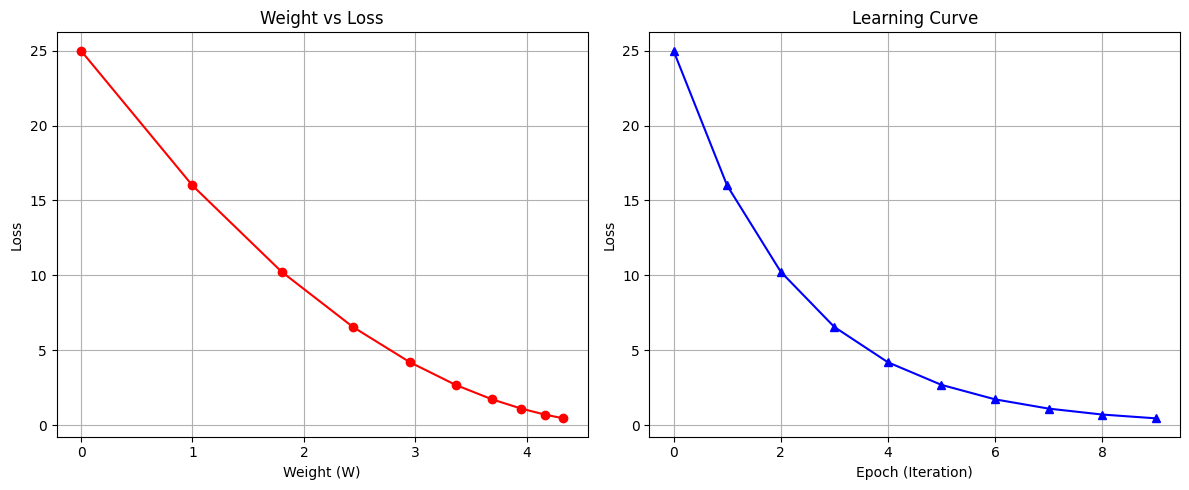

In [37]:
import matplotlib.pyplot as plt

def update_weight(x, y, W, learning_rate):
    y_hat = W * x
    gradient = 2 * x * (y_hat - y)
    loss = (y - y_hat)**2
    new_W = W - (learning_rate * gradient)
    return new_W, gradient, loss

# 설정값
x_data = 1.0
y_data = 5.0
current_W = 0.0  # 시각화를 위해 0부터 시작
lr = 0.1

w_history = []
loss_history = []

# 10회 반복 학습
for i in range(10):
    w_history.append(current_W)
    current_W, grad, loss = update_weight(x_data, y_data, current_W, lr)
    loss_history.append(loss)
    print(f"반복 {i+1}: W = {current_W:.4f}, Loss = {loss:.4f}")

# 시각화
plt.figure(figsize=(12, 5))

# 1. 가중치 변화에 따른 Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(w_history, loss_history, 'ro-')
plt.title('Weight vs Loss')
plt.xlabel('Weight (W)')
plt.ylabel('Loss')
plt.grid(True)

# 2. 반복 횟수에 따른 Loss 변화 (학습 곡선)
plt.subplot(1, 2, 2)
plt.plot(loss_history, 'b^-')
plt.title('Learning Curve')
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()
